In [2]:
import astropy.io.fits as fits
import numpy as np
from scipy.integrate import quad
import scipy.integrate as integrate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join
import os
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import halomod as hm
import hmf
import treecorr
import DarkVerse as dv




/home/astro/manasoi7/.conda/envs/project/lib/python3.12/site-packages/halomod/halo_model.py:32: UserWarning: Warning: Some Halo-Exclusion models have significant speedup when using Numba
  from .halo_exclusion import NoExclusion


# !! handle the star / galaxy separation
## Try with SN-C3 

In [3]:

home_dir = os.path.expanduser('~')
thesis_path = os.path.join(home_dir, 'Master_Thesis', 'DATA')


# Catalog
fits_file_path = os.path.join(thesis_path, "DES_DF_SN-C3_sbi_output.fits")  
t= Table.read(fits_file_path)
masked_file_path = os.path.join(thesis_path, "SN-C3_masked_cat.fits")  
t3= Table.read(masked_file_path)

# Join in one table
t=join(t,t3,keys='id') 
#t.rename_column('ra_1','ra')
#t.rename_column('dec_1','dec')
t.rename_column('mode_z','z')
t.rename_column('mode_mass','SM')



#!!! remove stars 
t = t[t['kNN_class'] != 2]
# Our main star / galaxy separation method in the DES DF is a kNN classifier, with the catalogue column kNN_CLASS. We should discard objects with values of 2.
# But that won't remove all stars, so we also want to use a compactness cut

# Load Randoms
fits_random = os.path.join(thesis_path, "SN-C3_randoms_ugriz_trim_video.fits") 
t2 = Table.read(fits_random)
randoms = t2  # Random catalog



In [4]:
t['kNN_class']

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


In [5]:
print(t.colnames)

print(type(t))


['id', 'z', 'SM', 'z_pcntiles', 'z_pdf', 'ra', 'dec', 'fof_id', 'fof_size', 'mask_flags', 'flags', 'flagstr', 'badpix_frac', 'psf_g_0', 'psf_g_1', 'psf_T', 'bdf_T', 'bdf_T_err', 'bdf_T_ratio', 'bdf_g_0', 'bdf_g_1', 'bdf_fracdev', 'bdf_fracdev_err', 'tilename', 'EBV_SFD98', 'mask_flags_nir', 'flags_nir', 'flagstr_nir', 'badpix_frac_nir', 'psf_flux_u', 'psf_flux_g', 'psf_flux_r', 'psf_flux_i', 'psf_flux_z', 'psf_flux_J', 'psf_flux_H', 'psf_flux_Ks', 'psf_flux_err_u', 'psf_flux_err_g', 'psf_flux_err_r', 'psf_flux_err_i', 'psf_flux_err_z', 'psf_flux_err_J', 'psf_flux_err_H', 'psf_flux_err_Ks', 'bdf_flux_u', 'bdf_flux_g', 'bdf_flux_r', 'bdf_flux_i', 'bdf_flux_z', 'bdf_flux_J', 'bdf_flux_H', 'bdf_flux_Ks', 'bdf_flux_err_u', 'bdf_flux_err_g', 'bdf_flux_err_r', 'bdf_flux_err_i', 'bdf_flux_err_z', 'bdf_flux_err_J', 'bdf_flux_err_H', 'bdf_flux_err_Ks', 'gap_flux_u', 'gap_flux_g', 'gap_flux_r', 'gap_flux_i', 'gap_flux_z', 'gap_flux_J', 'gap_flux_H', 'gap_flux_Ks', 'gap_flux_err_u', 'gap_flux_err_

In [6]:
print(t['psf_mag_dered_calib_i'])

psf_mag_dered_calib_i
---------------------
   24.334646753542877
   25.360745915348502
   20.716085898141817
    25.25089804540787
   25.648298035751793
   23.180468003033788
   26.035623081267012
   22.297118410980847
   22.524811936700956
   23.632215793729827
                  ...
   24.942420042010042
   25.939419676484174
     25.6943492680788
   26.387592254522847
   25.076662828340474
   26.116525480847038
    26.06020743147967
    26.10806940304986
   24.004612517723412
   26.005863658511156
Length = 314615 rows


In [7]:
delta_mag = t['bdf_mag_dered_calib_i'] - t['psf_mag_dered_calib_i']


In [8]:
print(len(delta_mag ) )
print(len(t['bdf_mag_dered_calib_i'] ) )

314615
314615


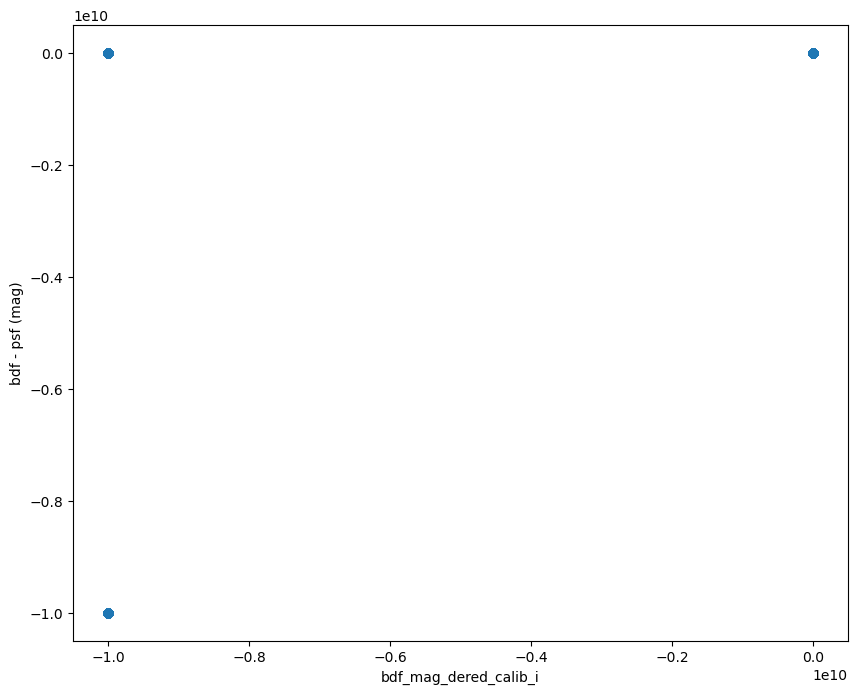

In [9]:
plt.figure(figsize=(10,8))
plt.scatter(t['bdf_mag_dered_calib_i'], delta_mag)
plt.xlabel('bdf_mag_dered_calib_i')
plt.ylabel('bdf - psf (mag)')
plt.show()

### ^ you can see that galaxies tend to have negative values in the magnitude difference axis (they're brighter in the bulge+disk model fit than PSF fit photometry) and stars have values ~0. So we want to define a cut in bdf - psf mag that removes compact objects that are not flagged by kNN_CLASS. 

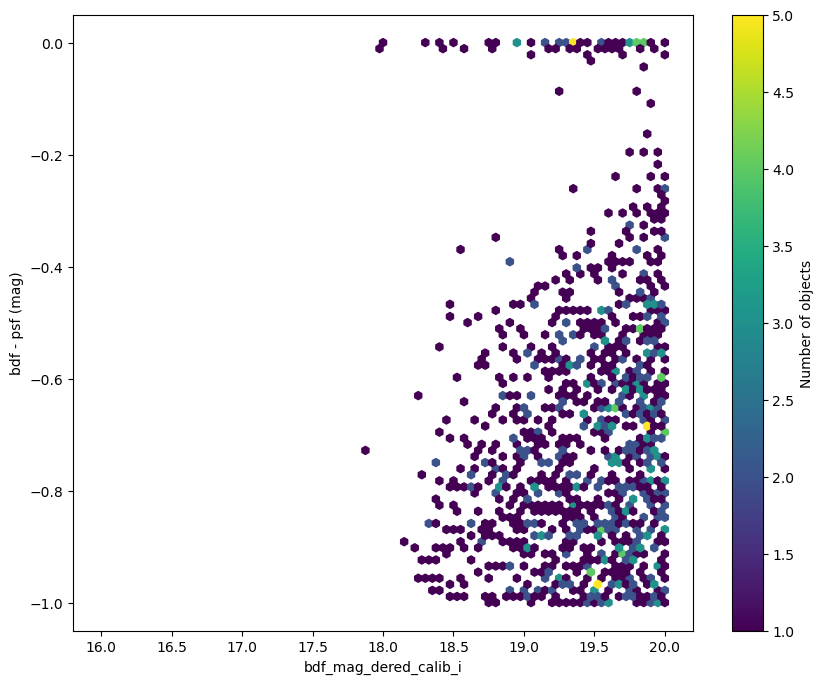

In [10]:
plt.figure(figsize=(10,8))
plt.hexbin( t['bdf_mag_dered_calib_i'], delta_mag, gridsize=80, cmap='viridis', mincnt=1, extent=(16,20, -1,0))
plt.colorbar(label='Number of objects')
plt.xlabel('bdf_mag_dered_calib_i')
plt.ylabel('bdf - psf (mag)')
plt.show()



In [11]:
print(len(np.where((t['bdf_mag_dered_calib_i']<22) & (delta_mag > -0.02))[0]))

661


In [12]:
# Check flagged objects
flagged_mask = (t['flags'] > 0) | (t['flags_nir'] > 0)  # flags>0 or flags_nir>0 

n_flagged = np.sum(flagged_mask)
n_total = len(t)
# what fraction of objects have flags>0 or flags_nir>0 after cross-matching with the masked cat
fraction_flagged = n_flagged / n_total

print(f"Number of objects flagged: {n_flagged}/{n_total}")
print(f"Fraction of flagged objects: {fraction_flagged:.3%}")


Number of objects flagged: 3204/314615
Fraction of flagged objects: 1.018%


#### If it's a small fraction (a few percent), then we can exclude them. We might need to anyway, they might not have valid values for the fluxes etc., so then it's just good to know how many there are. In the worst case we can run the measurements with and without them to test the sensitivity to that. Some of the objects are flagged due to fitting failures, and the risk is that those are more common in densely-populated regions, which is obviously going to affect our clustering measurements.

In [15]:
def load_and_clean_catalog(path, compactness_cut=0):
    """
    Read a FITS catalog and apply star/galaxy separation and flag cleaning.

    """
    cat = Table.read(path)

    # Remove stars 
    if 'kNN_class' in cat.colnames:
        cat = cat[cat['kNN_class'] != 2]

    # Compactness cut: Δm = bdf - psf 
    bdf_col = 'bdf_mag_dered_calib_i'
    psf_col = 'psf_mag_dered_calib_i'
    if bdf_col in cat.colnames and psf_col in cat.colnames:
        delta_mag = cat[bdf_col] - cat[psf_col]
        cat = cat[delta_mag < compactness_cut]

    return cat

def exclude_flagged_objects(cat):
    """
    Exclude objects with flags > 0 or flags_nir > 0.

    """
    flagged_mask = np.zeros(len(cat), dtype=bool)
    if 'flags' in cat.colnames:
        flagged_mask |= cat['flags'] > 0
    if 'flags_nir' in cat.colnames:
        flagged_mask |= cat['flags_nir'] > 0

    return cat[~flagged_mask]

fits_file_path = os.path.join(thesis_path, "DES_DF_SN-C3_sbi_output.fits")
t = load_and_clean_catalog(fits_file_path)
masked_file_path = os.path.join(thesis_path, "SN-C3_masked_cat.fits")
t3 = load_and_clean_catalog(masked_file_path)
t = join(t, t3, keys='id')
t.rename_column('mode_z', 'z')
t.rename_column('mode_mass', 'SM')
t = exclude_flagged_objects(t)

fits_random = os.path.join(thesis_path, "SN-C3_randoms_ugriz_trim_video.fits")
randoms = load_and_clean_catalog(fits_random)
randoms = exclude_flagged_objects(randoms)

print(f"Cleaned science catalog: {len(t)} objects")
print(f"Cleaned random catalog: {len(randoms)} objects")

Cleaned science catalog: 271783 objects
Cleaned random catalog: 13402307 objects


# Refactored multi-field HOD + SHMR pipeline

This section replaces the repeated per-field / per-bin blocks with a cached workflow.

What changed:
- catalogs are loaded and cleaned once, then reused
- all repeated selection + interpolation logic lives in helper functions
- SHMR extraction is handled in one place
- the final section runs the analysis twice:
  1. using all fields
  2. dropping **SN-E2**

This makes it easy to compare whether excluding SN-E2 gives a cleaner SHMR trend.

In [16]:
%matplotlib inline
plt.rc('font', **{'family': 'serif', 'size': 14})

# Correlation-function configuration
CONFIG = {
    'min_sep': 0.003,
    'max_sep': 1.78,
    'bin_size': 0.1,
    'sep_units': 'degrees',
    'var_method': 'shot'
}

Z_RANGE = (0.2, 0.5)
SM_BINS = [(8.5, 12.5), (9.5, 12.5), (10.5, 12.5)]

home_dir = os.path.expanduser('~')
thesis_path = os.path.join(home_dir, 'Master_Thesis', 'DATA')

ALL_FIELDS = {
    "SN-X3": {
        "catalog": "DES_DF_SN-X3_sbi_output.fits",
        "masked": "SN-X3_masked_cat.fits",
        "randoms": "SN-X3_randoms_ugriz_trim_video.fits"
    },
    "SN-C3": {
        "catalog": "DES_DF_SN-C3_sbi_output.fits",
        "masked": "SN-C3_masked_cat.fits",
        "randoms": "SN-C3_randoms_ugriz_trim_video.fits"
    },
    "SN-E2": {
        "catalog": "DES_DF_SN-E2_sbi_output.fits",
        "masked": "SN-E2_masked_cat.fits",
        "randoms": "SN-E2_randoms_ugriz_trim_video.fits"
    },
    "COSMOS": {
        "catalog": "DES_DF_COSMOS_sbi_output.fits",
        "masked": "COSMOS_masked_cat.fits",
        "randoms": "COSMOS_randoms_ugriz_trim_video.fits"
    }
}

FIELDS_NO_SNE2 = {k: v for k, v in ALL_FIELDS.items() if k != "SN-E2"}

FIELD_COLORS = {
    "SN-C3": "tab:blue",
    "SN-X3": "tab:orange",
    "COSMOS": "tab:red",
    "SN-E2": "tab:green"
}

In [17]:
from astropy.table import vstack

In [18]:
def load_catalog(path):
    cat = Table.read(path)

    # Lower-case column names once for safer downstream access
    old_cols = list(cat.colnames)
    new_cols = [c.lower() for c in old_cols]
    if old_cols != new_cols:
        cat.rename_columns(old_cols, new_cols)

    return cat


def remove_stars(cat, compactness_cut=-0.02):
    if 'knn_class' in cat.colnames:
        cat = cat[cat['knn_class'] != 2]

    bdf = 'bdf_mag_dered_calib_i'
    psf = 'psf_mag_dered_calib_i'
    if bdf in cat.colnames and psf in cat.colnames:
        delta = cat[bdf] - cat[psf]
        cat = cat[delta < compactness_cut]

    return cat


def remove_flagged(cat):
    mask = np.ones(len(cat), dtype=bool)
    if 'flags' in cat.colnames:
        mask &= (cat['flags'] == 0)
    if 'flags_nir' in cat.colnames:
        mask &= (cat['flags_nir'] == 0)
    return cat[mask]


def standardize_catalog(cat):
    cat = cat.copy()

    # Harmonize common column names only if needed
    rename_map = {
        'mode_z': 'z',
        'mode_mass': 'SM',
        'ra_1': 'ra',
        'dec_1': 'dec',
    }
    for old, new in rename_map.items():
        if old in cat.colnames and new not in cat.colnames:
            cat.rename_column(old, new)

    return cat


def clean_catalog(path):
    cat = load_catalog(path)
    cat = remove_stars(cat, compactness_cut=-0.02)
    cat = remove_flagged(cat)
    cat = standardize_catalog(cat)
    return cat


_catalog_cache = {}
_random_cache = {}


def get_clean_joined_catalog(field_name, field_paths):
    if field_name in _catalog_cache:
        return _catalog_cache[field_name].copy()

    cat = clean_catalog(os.path.join(thesis_path, field_paths["catalog"]))
    mask = clean_catalog(os.path.join(thesis_path, field_paths["masked"]))
    joined = join(cat, mask, keys='id')
    joined = standardize_catalog(joined)

    _catalog_cache[field_name] = joined
    return joined.copy()


def get_clean_randoms(field_name, field_paths):
    if field_name in _random_cache:
        return _random_cache[field_name].copy()

    rand = clean_catalog(os.path.join(thesis_path, field_paths["randoms"]))
    rand = standardize_catalog(rand)

    _random_cache[field_name] = rand
    return rand.copy()


def build_selection(field_name, field_paths, z_min, z_max, sm_min, sm_max, config):
    cat = get_clean_joined_catalog(field_name, field_paths)
    rand = get_clean_randoms(field_name, field_paths)

    sub = dv.Selection(
        cat,
        rand,
        z_min,
        z_max,
        sm_min,
        sm_max,
        config
    )
    sub.info = getattr(sub, 'info', {})
    sub.info['field_name'] = field_name
    sub.field_name = field_name
    return sub


def interpolate_selection_to_theta(selection, shared_theta):
    interp_w = interp1d(
        selection.theta,
        selection.w_theta,
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )
    interp_var = interp1d(
        selection.theta,
        selection.var_w_theta_bootstrap,
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )

    selection.w_theta = interp_w(shared_theta)
    selection.var_w_theta_bootstrap = interp_var(shared_theta)
    selection.theta = np.asarray(shared_theta)
    return selection

In [19]:
class MultiFieldHODFitter:
    def __init__(self, selections, fit_mask=(0.004, 0.4)):
        self.selections = selections
        self.fit_mask = fit_mask

        theta0 = np.asarray(selections[0].theta)
        for sel in selections[1:]:
            assert np.allclose(sel.theta, theta0), "All selections must share the same theta grid"

        self.theta = theta0
        self.mask = (self.theta >= fit_mask[0]) & (self.theta <= fit_mask[1])

    def _combined_model(self, theta_fit, logM_min_scaled, logM_1, alpha):
        model_parts = []
        for sel in self.selections:
            xi_g = sel.hod_model(logM_min_scaled * 1e7, logM_1, alpha)
            model_parts.append(np.asarray(xi_g)[self.mask])
        return np.concatenate(model_parts)

    def _combined_data(self):
        w_all, w_err_all = [], []
        for sel in self.selections:
            w_all.append(np.asarray(sel.w_theta)[self.mask])
            w_err_all.append(np.sqrt(np.asarray(sel.var_w_theta_bootstrap))[self.mask])
        return np.concatenate(w_all), np.concatenate(w_err_all)

    def fit(self, p0=None, bounds=None):
        if p0 is None:
            p0 = [12.3 * 1e-7, 13.5, 1.0]
        if bounds is None:
            bounds = ([11.0 * 1e-7, 12.5, 0.3], [14.5 * 1e-7, 15.5, 2.0])

        w_obs, w_err = self._combined_data()

        popt, pcov = curve_fit(
            self._combined_model,
            self.theta[self.mask],
            w_obs,
            sigma=w_err,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        for sel in self.selections:
            sel.hod_params = popt
            sel.xi_g = sel.hod_model(popt[0] * 1e7, popt[1], popt[2])

        return popt, pcov

In [20]:
def extract_threshold_mass_points(results_by_bin):
    rows = []
    for (sm_min, sm_max), result in results_by_bin.items():
        hod_params = result.get('hod_params')
        pcov = result.get('pcov')
        if hod_params is None or pcov is None:
            continue

        logM_min = hod_params[0] * 1e7
        logM_min_err = np.sqrt(pcov[0, 0]) * 1e7 if np.isfinite(pcov[0, 0]) else np.nan

        rows.append({
            'SM_min': sm_min,
            'SM_max': sm_max,
            'stellar_threshold': sm_min,
            'logM_halo': logM_min,
            'logM_halo_err': logM_min_err,
            'fields_used': ', '.join(result.get('fields_used', [])),
        })

    rows = sorted(rows, key=lambda r: r['stellar_threshold'])
    return rows


def build_shuntov22_reference():
    thresholds = np.array([8.5, 9.5, 10.5], dtype=float)

    Mhalo = np.array([
        66296706817.30795, 73917898798.73352, 82415191117.65851, 91889296602.63226, 102452505607.51738,
        114230016915.3509, 127361421637.34383, 142002357694.69983, 158326354492.74042, 176526889651.04785,
        196819682166.6986, 219445249189.9458, 244671756716.13455, 272798197981.23068, 304157937232.3985,
        339122660875.61456, 378106782830.6767, 421572356307.3892, 470034550218.98444, 524067755141.1132,
        584312391186.3297, 651482498483.3376, 726374200225.966, 809875138598.8401, 902974995417.5806,
        1006777222177.7738, 1122512118541.2837, 1251551414270.6223, 1395424527441.4702, 1555836691631.2769,
        1734689166933.6006, 1934101774346.0808, 2156438020617.3528, 2404333111341.2197, 2680725184318.9062,
        2988890133377.9307, 3332480435391.469, 3715568440689.3813, 4142694639953.733, 4618921479674.62,
        5149893364005.711, 5741903554181.688, 6401968758413.307, 7137912296323.953, 7958456823622.604,
        8873327716016.268, 9893368337705.371, 11030668560661.88, 12298708057947.068, 13712516069428.059,
        15288849533494.11, 17046391696047.846, 19005973550756.92, 21190820735148.2, 2404333111341.2197
    ], dtype=float)

    Mcent_50 = np.array([
        138185889.15720302, 172720900.0668386, 215673222.45576337, 269089919.88765955, 335515179.327528,
        418111484.28001314, 520828269.08945644, 648606120.6643087, 807610719.2412863, 1005539328.3203484,
        1252045100.3530602, 1559341768.9483867, 1942821473.3047915, 2421887213.518848, 3020837737.8737206,
        3768184888.123724, 4697571006.331157, 5849459111.900749, 7272065288.372202, 9012562604.540678,
        11103654734.995914, 13563337202.82329, 16383512911.519424, 19526092461.489563, 22964843744.2323,
        26653770811.350174, 30497339591.234303, 34332934621.112762, 38039137854.068245, 41580202752.4853,
        44960629691.55288, 48255164000.67649, 51559726515.37951, 54848574060.27377, 58074904513.471115,
        61195354453.304756, 64176275624.11628, 66982124975.57955, 69594247688.89069, 72041324787.95726,
        74431053359.4038, 76855424127.0457, 79317242371.72003, 81830017335.21799, 84437227153.89256,
        87197196144.7057, 90094865412.7629, 93078040073.30054, 96062580938.40805, 98928121262.40611,
        101605473415.01775, 104098955603.05504, 106479288961.97887, 108926724434.02715, 131113681632.74998
    ], dtype=float)

    Mcent_16 = np.array([
        122859549.08492075, 153463093.1277725, 191768882.6401075, 239526223.76712334, 298836177.16694885,
        372219547.2840017, 463052304.6707711, 575984089.142209, 717040702.2843549, 894038906.9945077,
        1116606899.1893206, 1395243177.6998365, 1742212577.8122094, 2171990261.733003, 2701881404.0431743,
        3356430344.5712314, 4169195559.5823936, 5183738595.810069, 6456409992.04091, 8037261534.242731,
        9941610303.771763, 12155006203.772999, 14615543931.667683, 17212255517.138123, 19873379026.627617,
        22520938757.34364, 25036248827.990265, 27250495293.425167, 29045929842.63774, 30407827062.838898,
        31407366014.24033, 32259098525.92094, 33224153465.373096, 34332008079.68556, 35556722949.82484,
        36839738462.00549, 38087147941.07143, 39256742347.15974, 40349198016.17066, 41392236424.72836,
        42456861702.30304, 43598950121.40022, 44811201739.4774, 46072871679.93738, 47348448049.77223,
        48595493415.716606, 49803988231.3955, 50986747058.85586, 52185980770.76462, 53483597074.1377,
        54927179481.6141, 56525638200.18852, 58283289227.600975, 60197536524.2768, 75233860276.46657
    ], dtype=float)

    Mcent_84 = np.array([
        151841683.43116438, 188804430.35792825, 234528445.9761902, 291627479.4423529, 363603417.5064963,
        455136384.68409896, 571674824.6189399, 719219189.8050666, 905012812.7288473, 1137794075.4261613,
        1428466573.0027277, 1791676007.004955, 2246154632.081757, 2815655554.5198855, 3529882573.2354293,
        4421325003.19453, 5525535085.792659, 6882740897.502729, 8537251211.159791, 10529464663.453302,
        12883561796.396748, 15602388043.97047, 18652262648.43852, 21963348732.300957, 25508669710.572273,
        29268192338.128353, 33203775236.438942, 37254202425.78185, 41370327876.53652, 45531477775.037155,
        49735616340.65336, 54015845050.07054, 58416390418.72675, 62921318405.1627, 67510561839.025604,
        72179252980.06393, 76942390560.4907, 81778926561.5444, 86648244541.48576, 91518589845.90186,
        96379988758.53552, 101225557692.34584, 106043833293.65878, 110866749981.52075, 115806777285.15465,
        121023457392.73651, 126511325700.39758, 132197429787.67732, 137965749705.99323, 143650476583.49664,
        149129962573.3049, 154348609108.23242, 159305987750.48944, 164101459416.9993, 195683907020.22842
    ], dtype=float)

    # flatten to 1D
    Mhalo = np.array(Mhalo).flatten()
    Mcent_50 = np.array(Mcent_50).flatten()
    Mcent_16 = np.array(Mcent_16).flatten()
    Mcent_84 = np.array(Mcent_84).flatten()

    # Convert to log10
    log_Mhalo = np.log10(Mhalo)
    log_Mcent_50 = np.log10(Mcent_50)
    log_Mcent_16 = np.log10(Mcent_16)
    log_Mcent_84 = np.log10(Mcent_84)

    # y-axis asymmetric errors
    y_err_lower = log_Mcent_50 - log_Mcent_16
    y_err_upper = log_Mcent_84 - log_Mcent_50
    y_err = np.array([y_err_lower, y_err_upper])

    # choose nearest points to thresholds
    indices = [np.argmin(np.abs(log_Mcent_50 - t)) for t in thresholds]

    x_points = log_Mhalo[indices]
    y_points = log_Mcent_50[indices]
    y_err_points = y_err[:, indices]

    rows = []
    for i in range(len(thresholds)):
        rows.append({
            'stellar_threshold': float(y_points[i]),
            'target_threshold': float(thresholds[i]),
            'logM_halo': float(x_points[i]),
            'stellar_err_lower': float(y_err_points[0, i]),
            'stellar_err_upper': float(y_err_points[1, i]),
        })
    return rows


def plot_shmr_threshold_comparison(all_fields_rows, no_sne2_rows, shuntov_rows):
    fig, ax = plt.subplots(figsize=(10, 7))

    if shuntov_rows:
        ax.errorbar(
            [r['logM_halo'] for r in shuntov_rows],
            [r['stellar_threshold'] for r in shuntov_rows],
            yerr=[
                [r['stellar_err_lower'] for r in shuntov_rows],
                [r['stellar_err_upper'] for r in shuntov_rows]
            ],
            fmt='o',
            capsize=5,
            label='Shuntov +22'
        )

    if all_fields_rows:
        ax.errorbar(
            [r['logM_halo'] for r in all_fields_rows],
            [r['stellar_threshold'] for r in all_fields_rows],
            xerr=[r['logM_halo_err'] for r in all_fields_rows],
            fmt='o-',
            capsize=5,
            label='This work (all fields)'
        )

    if no_sne2_rows:
        ax.errorbar(
            [r['logM_halo'] for r in no_sne2_rows],
            [r['stellar_threshold'] for r in no_sne2_rows],
            xerr=[r['logM_halo_err'] for r in no_sne2_rows],
            fmt='s--',
            capsize=5,
            label='This work (without SN-E2)'
        )

    ax.set_xlabel(r'$\log_{10}(M_{\mathrm{h}}/M_\odot)$')
    ax.set_ylabel(r'$\log_{10}(M_*/M_\odot)$ Threshold')
    ax.set_title('HOD-derived Halo Mass vs. Stellar Mass Threshold')
    ax.grid(True, ls='--', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()
    

In [21]:
def plot_joint_fit(field_selections, colors, sm_min, sm_max, fit_mask=(0.004, 0.4)):
    """
    Plot per-field angular clustering together with the joint HOD fit.

    This is intentionally lightweight and only relies on attributes that are
    already created by the fitting pipeline.
    """
    plt.figure(figsize=(7, 5))

    for sel in field_selections:
        field_name = getattr(sel, 'field_name', getattr(sel, 'name', 'Field'))
        theta = np.asarray(sel.theta)
        w_theta = np.asarray(sel.w_theta)
        yerr = np.sqrt(np.asarray(sel.var_w_theta_bootstrap))

        color = colors.get(field_name, None) if isinstance(colors, dict) else None

        plt.errorbar(
            theta, w_theta, yerr=yerr,
            fmt='o', ms=4, capsize=2,
            label=field_name, color=color, alpha=0.9
        )

        if hasattr(sel, 'xi_g') and sel.xi_g is not None:
            plt.plot(theta, np.asarray(sel.xi_g), '-', lw=1.8, color=color)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$w(\theta)$')
    plt.title(f'Joint HOD fit: $\\log_{{10}}(M_*/M_\odot)={sm_min:.1f}$–{sm_max:.1f}$')
    plt.grid(True, which='both', alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_703713/1682507143.py:31: SyntaxWarning: invalid escape sequence '\o'
  plt.title(f'Joint HOD fit: $\\log_{{10}}(M_*/M_\odot)={sm_min:.1f}$–{sm_max:.1f}$')


In [22]:
def run_joint_hod_analysis(fields, sm_bins, z_range, config, colors, plot_each_bin=True):
    z_min, z_max = z_range
    results_by_bin = {}

    for sm_min, sm_max in sm_bins:
        print(f"\n🔹 Processing stellar-mass bin {sm_min}–{sm_max}")

        first_field_name = next(iter(fields))
        first_selection = build_selection(
            first_field_name,
            fields[first_field_name],
            z_min,
            z_max,
            sm_min,
            sm_max,
            config
        )
        shared_theta = np.asarray(first_selection.theta)

        field_selections = []
        bias_eff_dict = {}

        for field_name, field_paths in fields.items():
            print(f"   • {field_name}")
            sub = build_selection(field_name, field_paths, z_min, z_max, sm_min, sm_max, config)
            sub = interpolate_selection_to_theta(sub, shared_theta)

            field_selections.append(sub)
            bias_eff_dict[field_name] = sub.gg.bias_effective_tracer

        fitter = MultiFieldHODFitter(field_selections)
        hod_params, pcov = fitter.fit(
            p0=[12.59 * 1e-7, 13.97, 1.0],
            bounds=([11.0 * 1e-7, 13.0, 0.99], [14.5 * 1e-7, 15.5, 1.01])
        )

        logM_min, logM_1, alpha = hod_params
        print(
            f"   ✅ Joint fit: logM_min = {logM_min * 1e7:.2f}, "
            f"logM_1 = {logM_1:.2f}, alpha = {alpha:.2f}"
        )

        results_by_bin[(sm_min, sm_max)] = {
            'field_selections': field_selections,
            'hod_params': hod_params,
            'pcov': pcov,
            'bias_eff': bias_eff_dict,
            'fields_used': list(fields.keys()),
        }

        if plot_each_bin:
            plot_joint_fit(field_selections, colors, sm_min, sm_max)

    return results_by_bin

### Pickle cache for HOD threshold measurements and fits

The expensive part is building each `DarkVerse.Selection` object and fitting the HOD. The cache below saves a **lightweight, pickle-safe** version of the results: HOD parameters, covariance matrices, field names, bias values, and the measured `w(θ)` arrays. It intentionally does **not** pickle the full `Selection` objects, because those can contain local functions that trigger errors such as `Can't pickle local object ...`.

Use `RERUN_HOD = False` to reuse existing pickle files. Set `RERUN_HOD = True` only when you changed the data selection, redshift bin, stellar-mass bins, HOD model, or fitting bounds and want to regenerate the cached results.

In [23]:
import pickle
import json
import hashlib
import re
from pathlib import Path

# Set this to True only when you intentionally want to recompute the expensive
# DarkVerse selections + HOD fits and overwrite the cached pickles.
RERUN_HOD = False

# Cache files are stored next to the DES data by default so they persist between notebook runs.
HOD_CACHE_DIR = Path(thesis_path) / "hod_pickles"
HOD_CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_VERSION = "shmr_threshold_hod_cache_v2"


def _clean_cache_label(label):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(label)).strip("_")


def _cache_payload(label, fields, sm_bins, z_range, config):
    """Only include stable, JSON-serialisable settings that define a run."""
    return {
        "cache_version": CACHE_VERSION,
        "label": str(label),
        "field_names": list(fields.keys()),
        "field_paths": fields,
        "sm_bins": [list(x) for x in sm_bins],
        "z_range": list(z_range),
        "config": dict(config),
        # The fit settings are hard-coded inside run_joint_hod_analysis; include them
        # in the key so changing them later can be versioned explicitly.
        "fit_p0": [12.59, 13.97, 1.0],
        "fit_bounds": [[11.0, 13.0, 0.99], [14.5, 15.5, 1.01]],
    }


def hod_cache_path(label, fields, sm_bins, z_range, config):
    payload = _cache_payload(label, fields, sm_bins, z_range, config)
    digest = hashlib.md5(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    z_txt = f"z{z_range[0]:.2f}_{z_range[1]:.2f}".replace(".", "p")
    filename = f"{_clean_cache_label(label)}_{z_txt}_{digest}.pkl"
    return HOD_CACHE_DIR / filename


def _selection_to_pickle_safe_summary(sel):
    field_name = getattr(sel, "field_name", None)
    if field_name is None and hasattr(sel, "info"):
        field_name = sel.info.get("field_name")
    if field_name is None:
        field_name = getattr(sel, "name", "Field")

    gg = getattr(sel, "gg", None)
    bias = getattr(gg, "bias_effective_tracer", np.nan)

    return {
        "field_name": field_name,
        "theta": np.asarray(sel.theta),
        "w_theta": np.asarray(sel.w_theta),
        "var_w_theta_bootstrap": np.asarray(sel.var_w_theta_bootstrap),
        "xi_g": np.asarray(sel.xi_g) if hasattr(sel, "xi_g") and sel.xi_g is not None else None,
        "bias_effective_tracer": bias,
    }


def make_pickle_safe_results(results_by_bin):
    """Strip out unpickleable DarkVerse objects while preserving all plot/extract info."""
    safe = {}
    for sm_bin, result in results_by_bin.items():
        sm_key = tuple(float(x) for x in sm_bin)
        safe[sm_key] = {
            "hod_params": np.asarray(result.get("hod_params"), dtype=float),
            "pcov": np.asarray(result.get("pcov"), dtype=float),
            "bias_eff": dict(result.get("bias_eff", {})),
            "fields_used": list(result.get("fields_used", [])),
            "field_measurements": [
                _selection_to_pickle_safe_summary(sel)
                for sel in result.get("field_selections", [])
            ],
        }
    return safe


def save_hod_pickle(results_by_bin, cache_path):
    safe = make_pickle_safe_results(results_by_bin)
    with open(cache_path, "wb") as f:
        pickle.dump(safe, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"💾 Saved pickle cache: {cache_path}")
    return safe


def load_hod_pickle(cache_path):
    with open(cache_path, "rb") as f:
        cached = pickle.load(f)
    print(f"📦 Loaded pickle cache: {cache_path}")
    return cached


def plot_cached_joint_fit(cached_result, colors, sm_min, sm_max):
    """Plot cached w(theta) arrays without rebuilding DarkVerse.Selection objects."""
    plt.figure(figsize=(7, 5))

    for item in cached_result.get("field_measurements", []):
        field_name = item.get("field_name", "Field")
        theta = np.asarray(item["theta"])
        w_theta = np.asarray(item["w_theta"])
        yerr = np.sqrt(np.asarray(item["var_w_theta_bootstrap"]))
        xi_g = item.get("xi_g")
        color = colors.get(field_name, None) if isinstance(colors, dict) else None

        plt.errorbar(
            theta, w_theta, yerr=yerr,
            fmt="o", ms=4, capsize=2,
            label=field_name, color=color, alpha=0.9,
        )
        if xi_g is not None:
            plt.plot(theta, np.asarray(xi_g), "-", lw=1.8, color=color)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$w(\theta)$")
    plt.title(f"Cached joint HOD fit: $\\log_{{10}}(M_*/M_\\odot)={sm_min:.1f}$–{sm_max:.1f}$")
    plt.grid(True, which="both", alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def maybe_run_joint_hod_analysis(
    label,
    fields,
    sm_bins,
    z_range,
    config,
    colors,
    plot_each_bin=True,
    rerun=False,
):
    """
    Load cached lightweight HOD results when available, otherwise run the expensive
    DarkVerse measurements/fits and save them to pickle.
    """
    cache_path = hod_cache_path(label, fields, sm_bins, z_range, config)

    if cache_path.exists() and not rerun:
        cached = load_hod_pickle(cache_path)
        if plot_each_bin:
            for (sm_min, sm_max), cached_result in cached.items():
                plot_cached_joint_fit(cached_result, colors, sm_min, sm_max)
        return cached

    if rerun and cache_path.exists():
        print(f"🔁 RERUN_HOD=True, ignoring existing cache: {cache_path}")
    else:
        print(f"🧮 No cache found for {label}; running measurements and HOD fits.")

    results = run_joint_hod_analysis(
        fields=fields,
        sm_bins=sm_bins,
        z_range=z_range,
        config=config,
        colors=colors,
        plot_each_bin=plot_each_bin,
    )
    return save_hod_pickle(results, cache_path)



## Run the SHMR threshold comparison

This runs the joint HOD fit twice:
1. with all fields
2. without **SN-E2**

Then it compares both against the **Shuntov +22** reference at stellar-mass thresholds
$\log_{10}(M_*/M_\odot) = 8.5, 9.5, 10.5$.


**Note:** Shuntov +22 points are plotted with vertical error bars only (`yerr`), matching the comparison style in `Paper_correction-4.ipynb`.

📦 Loaded pickle cache: /home/astro/manasoi7/Master_Thesis/DATA/hod_pickles/all_fields_z0p20_0p50_b21418ab94d6.pkl


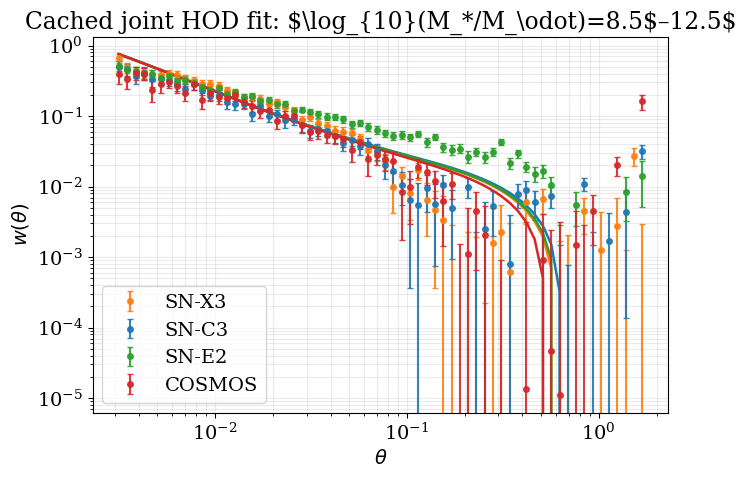

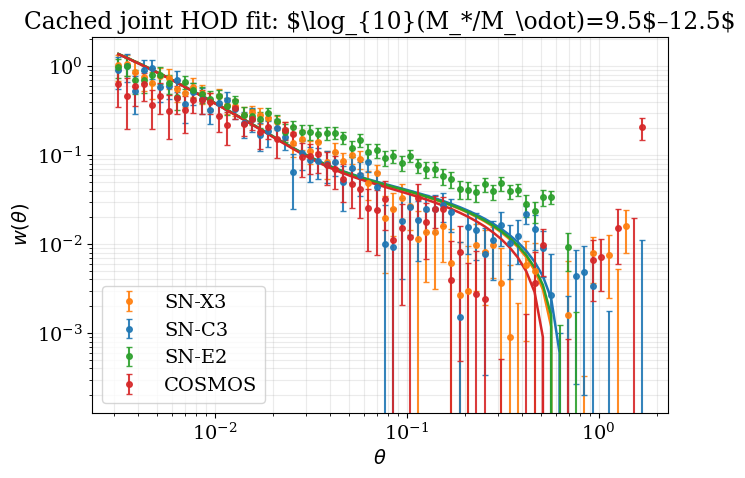

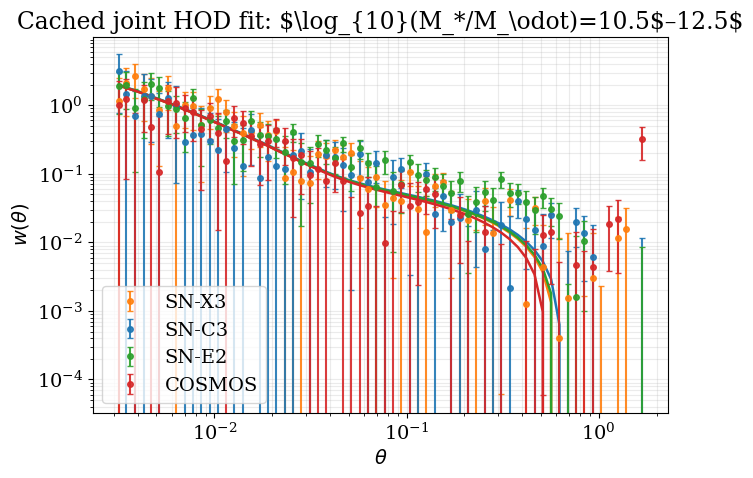

🧮 No cache found for without_SN-E2; running measurements and HOD fits.

🔹 Processing stellar-mass bin 8.5–12.5


In [ ]:
results_all_fields = maybe_run_joint_hod_analysis(
    label='all_fields',
    fields=ALL_FIELDS,
    sm_bins=SM_BINS,
    z_range=Z_RANGE,
    config=CONFIG,
    colors=FIELD_COLORS,
    plot_each_bin=True,
    rerun=RERUN_HOD,
)

results_no_sne2 = maybe_run_joint_hod_analysis(
    label='without_SN-E2',
    fields=FIELDS_NO_SNE2,
    sm_bins=SM_BINS,
    z_range=Z_RANGE,
    config=CONFIG,
    colors=FIELD_COLORS,
    plot_each_bin=True,
    rerun=RERUN_HOD,
)

threshold_all_fields = extract_threshold_mass_points(results_all_fields)
threshold_no_sne2 = extract_threshold_mass_points(results_no_sne2)
shuntov22_rows = build_shuntov22_reference()

print("All fields:")
for row in threshold_all_fields:
    print(row)

print("\nWithout SN-E2:")
for row in threshold_no_sne2:
    print(row)

print("\nShuntov +22:")
for row in shuntov22_rows:
    print(row)

plot_shmr_threshold_comparison(threshold_all_fields, threshold_no_sne2, shuntov22_rows)


In [ ]:
def extract_threshold_mass_points(results_by_bin):
    rows = []
    for (sm_min, sm_max), result in results_by_bin.items():
        hod_params = result.get('hod_params')
        pcov = result.get('pcov')
        if hod_params is None or pcov is None:
            continue

        logM_min = hod_params[0] * 1e7
        logM_min_err = np.sqrt(pcov[0, 0]) * 1e7 if np.isfinite(pcov[0, 0]) else np.nan

        rows.append({
            'SM_min': sm_min,
            'SM_max': sm_max,
            'stellar_threshold': sm_min,
            'logM_halo': logM_min,
            'logM_halo_err': logM_min_err,
            'fields_used': ', '.join(result.get('fields_used', [])),
        })

    rows = sorted(rows, key=lambda r: r['stellar_threshold'])
    return rows


def build_shuntov22_reference():
    thresholds = np.array([8.5, 9.5, 10.5], dtype=float)

    Mhalo = np.array([
        66296706817.30795, 73917898798.73352, 82415191117.65851, 91889296602.63226, 102452505607.51738,
        114230016915.3509, 127361421637.34383, 142002357694.69983, 158326354492.74042, 176526889651.04785,
        196819682166.6986, 219445249189.9458, 244671756716.13455, 272798197981.23068, 304157937232.3985,
        339122660875.61456, 378106782830.6767, 421572356307.3892, 470034550218.98444, 524067755141.1132,
        584312391186.3297, 651482498483.3376, 726374200225.966, 809875138598.8401, 902974995417.5806,
        1006777222177.7738, 1122512118541.2837, 1251551414270.6223, 1395424527441.4702, 1555836691631.2769,
        1734689166933.6006, 1934101774346.0808, 2156438020617.3528, 2404333111341.2197, 2680725184318.9062,
        2988890133377.9307, 3332480435391.469, 3715568440689.3813, 4142694639953.733, 4618921479674.62,
        5149893364005.711, 5741903554181.688, 6401968758413.307, 7137912296323.953, 7958456823622.604,
        8873327716016.268, 9893368337705.371, 11030668560661.88, 12298708057947.068, 13712516069428.059,
        15288849533494.11, 17046391696047.846, 19005973550756.92, 21190820735148.2, 2404333111341.2197
    ], dtype=float)

    Mcent_50 = np.array([
        138185889.15720302, 172720900.0668386, 215673222.45576337, 269089919.88765955, 335515179.327528,
        418111484.28001314, 520828269.08945644, 648606120.6643087, 807610719.2412863, 1005539328.3203484,
        1252045100.3530602, 1559341768.9483867, 1942821473.3047915, 2421887213.518848, 3020837737.8737206,
        3768184888.123724, 4697571006.331157, 5849459111.900749, 7272065288.372202, 9012562604.540678,
        11103654734.995914, 13563337202.82329, 16383512911.519424, 19526092461.489563, 22964843744.2323,
        26653770811.350174, 30497339591.234303, 34332934621.112762, 38039137854.068245, 41580202752.4853,
        44960629691.55288, 48255164000.67649, 51559726515.37951, 54848574060.27377, 58074904513.471115,
        61195354453.304756, 64176275624.11628, 66982124975.57955, 69594247688.89069, 72041324787.95726,
        74431053359.4038, 76855424127.0457, 79317242371.72003, 81830017335.21799, 84437227153.89256,
        87197196144.7057, 90094865412.7629, 93078040073.30054, 96062580938.40805, 98928121262.40611,
        101605473415.01775, 104098955603.05504, 106479288961.97887, 108926724434.02715, 131113681632.74998
    ], dtype=float)

    Mcent_16 = np.array([
        122859549.08492075, 153463093.1277725, 191768882.6401075, 239526223.76712334, 298836177.16694885,
        372219547.2840017, 463052304.6707711, 575984089.142209, 717040702.2843549, 894038906.9945077,
        1116606899.1893206, 1395243177.6998365, 1742212577.8122094, 2171990261.733003, 2701881404.0431743,
        3356430344.5712314, 4169195559.5823936, 5183738595.810069, 6456409992.04091, 8037261534.242731,
        9941610303.771763, 12155006203.772999, 14615543931.667683, 17212255517.138123, 19873379026.627617,
        22520938757.34364, 25036248827.990265, 27250495293.425167, 29045929842.63774, 30407827062.838898,
        31407366014.24033, 32259098525.92094, 33224153465.373096, 34332008079.68556, 35556722949.82484,
        36839738462.00549, 38087147941.07143, 39256742347.15974, 40349198016.17066, 41392236424.72836,
        42456861702.30304, 43598950121.40022, 44811201739.4774, 46072871679.93738, 47348448049.77223,
        48595493415.716606, 49803988231.3955, 50986747058.85586, 52185980770.76462, 53483597074.1377,
        54927179481.6141, 56525638200.18852, 58283289227.600975, 60197536524.2768, 75233860276.46657
    ], dtype=float)

    Mcent_84 = np.array([
        151841683.43116438, 188804430.35792825, 234528445.9761902, 291627479.4423529, 363603417.5064963,
        455136384.68409896, 571674824.6189399, 719219189.8050666, 905012812.7288473, 1137794075.4261613,
        1428466573.0027277, 1791676007.004955, 2246154632.081757, 2815655554.5198855, 3529882573.2354293,
        4421325003.19453, 5525535085.792659, 6882740897.502729, 8537251211.159791, 10529464663.453302,
        12883561796.396748, 15602388043.97047, 18652262648.43852, 21963348732.300957, 25508669710.572273,
        29268192338.128353, 33203775236.438942, 37254202425.78185, 41370327876.53652, 45531477775.037155,
        49735616340.65336, 54015845050.07054, 58416390418.72675, 62921318405.1627, 67510561839.025604,
        72179252980.06393, 76942390560.4907, 81778926561.5444, 86648244541.48576, 91518589845.90186,
        96379988758.53552, 101225557692.34584, 106043833293.65878, 110866749981.52075, 115806777285.15465,
        121023457392.73651, 126511325700.39758, 132197429787.67732, 137965749705.99323, 143650476583.49664,
        149129962573.3049, 154348609108.23242, 159305987750.48944, 164101459416.9993, 195683907020.22842
    ], dtype=float)

    # flatten to 1D
    Mhalo = np.array(Mhalo).flatten()
    Mcent_50 = np.array(Mcent_50).flatten()
    Mcent_16 = np.array(Mcent_16).flatten()
    Mcent_84 = np.array(Mcent_84).flatten()

    # Convert to log10
    log_Mhalo = np.log10(Mhalo)
    log_Mcent_50 = np.log10(Mcent_50)
    log_Mcent_16 = np.log10(Mcent_16)
    log_Mcent_84 = np.log10(Mcent_84)

    # y-axis asymmetric errors
    y_err_lower = log_Mcent_50 - log_Mcent_16
    y_err_upper = log_Mcent_84 - log_Mcent_50
    y_err = np.array([y_err_lower, y_err_upper])

    # choose nearest points to thresholds
    indices = [np.argmin(np.abs(log_Mcent_50 - t)) for t in thresholds]

    x_points = log_Mhalo[indices]
    y_points = log_Mcent_50[indices]
    y_err_points = y_err[:, indices]

    rows = []
    for i in range(len(thresholds)):
        rows.append({
            'stellar_threshold': float(y_points[i]),
            'target_threshold': float(thresholds[i]),
            'logM_halo': float(x_points[i]),
            'stellar_err_lower': float(y_err_points[0, i]),
            'stellar_err_upper': float(y_err_points[1, i]),
        })
    return rows


def plot_shmr_threshold_comparison(all_fields_rows, no_sne2_rows, shuntov_rows):
    fig, ax = plt.subplots(figsize=(10, 7))

    if shuntov_rows:
        ax.errorbar(
            [r['logM_halo'] for r in shuntov_rows],
            [r['stellar_threshold'] for r in shuntov_rows],
            yerr=[
                [r['stellar_err_lower'] for r in shuntov_rows],
                [r['stellar_err_upper'] for r in shuntov_rows]
            ],
            fmt='o',
            capsize=5,
            label='Shuntov +22'
        )

    if all_fields_rows:
        ax.errorbar(
            [r['logM_halo'] for r in all_fields_rows],
            [r['stellar_threshold'] for r in all_fields_rows],
            xerr=[r['logM_halo_err'] for r in all_fields_rows],
            fmt='o-',
            capsize=5,
            label='This work (all fields)'
        )

    if no_sne2_rows:
        ax.errorbar(
            [r['logM_halo'] for r in no_sne2_rows],
            [r['stellar_threshold'] for r in no_sne2_rows],
            xerr=[r['logM_halo_err'] for r in no_sne2_rows],
            fmt='s--',
            capsize=5,
            label='This work (without SN-E2)'
        )

    ax.set_xlabel(r'$\log_{10}(M_{\mathrm{h}}/M_\odot)$')
    ax.set_ylabel(r'$\log_{10}(M_*/M_\odot)$ Threshold')
    ax.set_title('HOD-derived Halo Mass vs. Stellar Mass Threshold')
    ax.grid(True, ls='--', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()
    

In [ ]:

def threshold_rows_to_table(rows, label):
    table_rows = []
    for r in rows:
        table_rows.append((
            label,
            r.get('stellar_threshold', np.nan),
            r.get('target_threshold', np.nan),
            r.get('logM_halo', np.nan),
            r.get('logM_halo_err', np.nan),
            r.get('stellar_err_lower', np.nan),
            r.get('stellar_err_upper', np.nan),
            r.get('fields_used', ''),
        ))

    return Table(
        rows=table_rows,
        names=[
            'run',
            'stellar_threshold',
            'target_threshold',
            'logM_halo',
            'logM_halo_err',
            'stellar_err_lower',
            'stellar_err_upper',
            'fields_used',
        ]
    )

summary_table = Table()
tables_to_stack = []

if threshold_all_fields:
    tables_to_stack.append(threshold_rows_to_table(threshold_all_fields, 'all_fields'))

if threshold_no_sne2:
    tables_to_stack.append(threshold_rows_to_table(threshold_no_sne2, 'no_SN-E2'))

if shuntov22_rows:
    tables_to_stack.append(threshold_rows_to_table(shuntov22_rows, 'Shuntov+22'))

if tables_to_stack:
    summary_table = vstack(tables_to_stack)

summary_table


In [ ]:
plot_shmr_threshold_comparison(threshold_all_fields, threshold_no_sne2, shuntov22_rows)


In [ ]:
results_all_fields = maybe_run_joint_hod_analysis(
    label='all_fields',
    fields=ALL_FIELDS,
    sm_bins=SM_BINS,
    z_range=Z_RANGE,
    config=CONFIG,
    colors=FIELD_COLORS,
    plot_each_bin=False,
    rerun=RERUN_HOD,
)

results_no_sne2 = maybe_run_joint_hod_analysis(
    label='without_SN-E2',
    fields=FIELDS_NO_SNE2,
    sm_bins=SM_BINS,
    z_range=Z_RANGE,
    config=CONFIG,
    colors=FIELD_COLORS,
    plot_each_bin=False,
    rerun=RERUN_HOD,
)

all_fields_rows = extract_threshold_mass_points(results_all_fields)
no_sne2_rows = extract_threshold_mass_points(results_no_sne2)
shuntov_rows = build_shuntov22_reference()

plot_shmr_threshold_comparison(all_fields_rows, no_sne2_rows, shuntov_rows)


## COSMOS-only SHMR comparison against Shuntov +22

This section fits the same stellar-mass threshold bins using **only the COSMOS field**, then plots those HOD-derived halo masses against the Shuntov +22 reference points. Shuntov +22 is still plotted with vertical error bars only (`yerr`).


In [ ]:
COSMOS_ONLY_FIELDS = {"COSMOS": ALL_FIELDS["COSMOS"]}


def plot_cosmos_shuntov_comparison(cosmos_rows, shuntov_rows):
    fig, ax = plt.subplots(figsize=(9, 6.5))

    if shuntov_rows:
        ax.errorbar(
            [r['logM_halo'] for r in shuntov_rows],
            [r['stellar_threshold'] for r in shuntov_rows],
            yerr=[
                [r['stellar_err_lower'] for r in shuntov_rows],
                [r['stellar_err_upper'] for r in shuntov_rows]
            ],
            fmt='o',
            capsize=5,
            label='Shuntov +22'
        )

    if cosmos_rows:
        ax.errorbar(
            [r['logM_halo'] for r in cosmos_rows],
            [r['stellar_threshold'] for r in cosmos_rows],
            xerr=[r['logM_halo_err'] for r in cosmos_rows],
            fmt='s-',
            capsize=5,
            label='This work: COSMOS only'
        )

    ax.set_xlabel(r'$\log_{10}(M_{\mathrm{h}}/M_\odot)$')
    ax.set_ylabel(r'$\log_{10}(M_*/M_\odot)$ Threshold')
    ax.set_title(
        rf'COSMOS-only SHMR threshold comparison, '
        rf'${Z_RANGE[0]} < z < {Z_RANGE[1]}$'
    )
    ax.grid(True, ls='--', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()


results_cosmos_only = maybe_run_joint_hod_analysis(
    label='COSMOS_only',
    fields=COSMOS_ONLY_FIELDS,
    sm_bins=SM_BINS,
    z_range=Z_RANGE,
    config=CONFIG,
    colors=FIELD_COLORS,
    plot_each_bin=False,
    rerun=RERUN_HOD,
)

cosmos_only_rows = extract_threshold_mass_points(results_cosmos_only)
shuntov_rows = build_shuntov22_reference()

print("COSMOS only:")
for row in cosmos_only_rows:
    print(row)

plot_cosmos_shuntov_comparison(cosmos_only_rows, shuntov_rows)



## Final SHMR comparison: COSMOS-only, all fields, and Shuntov +22

This version is meant to be the cleaner thesis/paper diagnostic. It keeps the Shuntov et al. (2022) comparison as a **full central-galaxy SHMR curve with its 1σ band**, and overlays three versions of our clustering-only threshold result:

1. **COSMOS only**, which is the closest field-to-field comparison to Shuntov because Shuntov use COSMOS2020.
2. **All four DES Deep Fields**, which is the measurement designed to reduce cosmic variance.
3. **All fields except SN-E2**, which is a stress test for whether one field is driving the combined result.

The bottom panel compares each of our threshold points to Shuntov at the same stellar-mass threshold by interpolating the Shuntov central SHMR in the horizontal direction. Positive values of ΔlogMh mean our clustering fit assigns a higher halo mass than the Shuntov central-SHMR value at the same stellar mass threshold.


In [ ]:
def build_shuntov22_digitized_curve(rescale_to_this_cosmology=False, h_shuntov=0.70, h_this=0.67):
    thresholds = np.array([8.5, 9.5, 10.5], dtype=float)

    Mhalo = np.array([
        66296706817.30795, 73917898798.73352, 82415191117.65851, 91889296602.63226, 102452505607.51738,
        114230016915.3509, 127361421637.34383, 142002357694.69983, 158326354492.74042, 176526889651.04785,
        196819682166.6986, 219445249189.9458, 244671756716.13455, 272798197981.23068, 304157937232.3985,
        339122660875.61456, 378106782830.6767, 421572356307.3892, 470034550218.98444, 524067755141.1132,
        584312391186.3297, 651482498483.3376, 726374200225.966, 809875138598.8401, 902974995417.5806,
        1006777222177.7738, 1122512118541.2837, 1251551414270.6223, 1395424527441.4702, 1555836691631.2769,
        1734689166933.6006, 1934101774346.0808, 2156438020617.3528, 2404333111341.2197, 2680725184318.9062,
        2988890133377.9307, 3332480435391.469, 3715568440689.3813, 4142694639953.733, 4618921479674.62,
        5149893364005.711, 5741903554181.688, 6401968758413.307, 7137912296323.953, 7958456823622.604,
        8873327716016.268, 9893368337705.371, 11030668560661.88, 12298708057947.068, 13712516069428.059,
        15288849533494.11, 17046391696047.846, 19005973550756.92, 21190820735148.2, 2404333111341.2197
    ], dtype=float)

    Mcent_50 = np.array([
        138185889.15720302, 172720900.0668386, 215673222.45576337, 269089919.88765955, 335515179.327528,
        418111484.28001314, 520828269.08945644, 648606120.6643087, 807610719.2412863, 1005539328.3203484,
        1252045100.3530602, 1559341768.9483867, 1942821473.3047915, 2421887213.518848, 3020837737.8737206,
        3768184888.123724, 4697571006.331157, 5849459111.900749, 7272065288.372202, 9012562604.540678,
        11103654734.995914, 13563337202.82329, 16383512911.519424, 19526092461.489563, 22964843744.2323,
        26653770811.350174, 30497339591.234303, 34332934621.112762, 38039137854.068245, 41580202752.4853,
        44960629691.55288, 48255164000.67649, 51559726515.37951, 54848574060.27377, 58074904513.471115,
        61195354453.304756, 64176275624.11628, 66982124975.57955, 69594247688.89069, 72041324787.95726,
        74431053359.4038, 76855424127.0457, 79317242371.72003, 81830017335.21799, 84437227153.89256,
        87197196144.7057, 90094865412.7629, 93078040073.30054, 96062580938.40805, 98928121262.40611,
        101605473415.01775, 104098955603.05504, 106479288961.97887, 108926724434.02715, 131113681632.74998
    ], dtype=float)

    Mcent_16 = np.array([
        122859549.08492075, 153463093.1277725, 191768882.6401075, 239526223.76712334, 298836177.16694885,
        372219547.2840017, 463052304.6707711, 575984089.142209, 717040702.2843549, 894038906.9945077,
        1116606899.1893206, 1395243177.6998365, 1742212577.8122094, 2171990261.733003, 2701881404.0431743,
        3356430344.5712314, 4169195559.5823936, 5183738595.810069, 6456409992.04091, 8037261534.242731,
        9941610303.771763, 12155006203.772999, 14615543931.667683, 17212255517.138123, 19873379026.627617,
        22520938757.34364, 25036248827.990265, 27250495293.425167, 29045929842.63774, 30407827062.838898,
        31407366014.24033, 32259098525.92094, 33224153465.373096, 34332008079.68556, 35556722949.82484,
        36839738462.00549, 38087147941.07143, 39256742347.15974, 40349198016.17066, 41392236424.72836,
        42456861702.30304, 43598950121.40022, 44811201739.4774, 46072871679.93738, 47348448049.77223,
        48595493415.716606, 49803988231.3955, 50986747058.85586, 52185980770.76462, 53483597074.1377,
        54927179481.6141, 56525638200.18852, 58283289227.600975, 60197536524.2768, 75233860276.46657
    ], dtype=float)

    Mcent_84 = np.array([
        151841683.43116438, 188804430.35792825, 234528445.9761902, 291627479.4423529, 363603417.5064963,
        455136384.68409896, 571674824.6189399, 719219189.8050666, 905012812.7288473, 1137794075.4261613,
        1428466573.0027277, 1791676007.004955, 2246154632.081757, 2815655554.5198855, 3529882573.2354293,
        4421325003.19453, 5525535085.792659, 6882740897.502729, 8537251211.159791, 10529464663.453302,
        12883561796.396748, 15602388043.97047, 18652262648.43852, 21963348732.300957, 25508669710.572273,
        29268192338.128353, 33203775236.438942, 37254202425.78185, 41370327876.53652, 45531477775.037155,
        49735616340.65336, 54015845050.07054, 58416390418.72675, 62921318405.1627, 67510561839.025604,
        72179252980.06393, 76942390560.4907, 81778926561.5444, 86648244541.48576, 91518589845.90186,
        96379988758.53552, 101225557692.34584, 106043833293.65878, 110866749981.52075, 115806777285.15465,
        121023457392.73651, 126511325700.39758, 132197429787.67732, 137965749705.99323, 143650476583.49664,
        149129962573.3049, 154348609108.23242, 159305987750.48944, 164101459416.9993, 195683907020.22842
    ], dtype=float)

    # flatten to 1D
    Mhalo = np.array(Mhalo).flatten()
    Mcent_50 = np.array(Mcent_50).flatten()
    Mcent_16 = np.array(Mcent_16).flatten()
    Mcent_84 = np.array(Mcent_84).flatten()

    # Convert to log10
    log_Mhalo = np.log10(Mhalo)
    log_Mcent_50 = np.log10(Mcent_50)
    log_Mcent_16 = np.log10(Mcent_16)
    log_Mcent_84 = np.log10(Mcent_84)



    # Optional cosmology conversion.
    # Shuntov et al. adopt h=0.70; this notebook uses h≈0.67.
    # Halo masses scale approximately as h^-1 and stellar masses as h^-2.
    if rescale_to_this_cosmology:
        log_Mhalo = log_Mhalo + np.log10(h_shuntov / h_this)
        log_Mcent_50 = log_Mcent_50 + 2.0 * np.log10(h_shuntov / h_this)
        log_Mcent_16 = log_Mcent_16 + 2.0 * np.log10(h_shuntov / h_this)
        log_Mcent_84 = log_Mcent_84 + 2.0 * np.log10(h_shuntov / h_this)

    # The digitised table contains one final out-of-order point. It is not used for the threshold
    # comparison and it makes the full line visually loop back, so drop it for the curve plot.
    monotonic_mask = np.r_[True, np.diff(log_Mhalo) > 0]
    if not np.all(monotonic_mask):
        n_drop = np.size(monotonic_mask) - int(np.sum(monotonic_mask))
        print(f"Dropped {n_drop} non-monotonic digitised Shuntov point(s) from the full curve plot.")

    log_Mhalo = log_Mhalo[monotonic_mask]
    log_Mcent_50 = log_Mcent_50[monotonic_mask]
    log_Mcent_16 = log_Mcent_16[monotonic_mask]
    log_Mcent_84 = log_Mcent_84[monotonic_mask]

    order = np.argsort(log_Mhalo)
    return {
        'log_Mhalo': log_Mhalo[order],
        'log_Mstar_50': log_Mcent_50[order],
        'log_Mstar_16': log_Mcent_16[order],
        'log_Mstar_84': log_Mcent_84[order],
    }



def shuntov_halo_mass_at_stellar_threshold(stellar_threshold, curve=None, **curve_kwargs):
    """Invert the digitised Shuntov central SHMR at a fixed log10 stellar-mass threshold.

    Returns the median log halo mass and an approximate asymmetric horizontal uncertainty
    by inverting the 84th and 16th percentile stellar-mass curves.
    """
    if curve is None:
        curve = build_shuntov22_digitized_curve(**curve_kwargs)

    x = np.asarray(curve['log_Mhalo'], dtype=float)
    y50 = np.asarray(curve['log_Mstar_50'], dtype=float)
    y16 = np.asarray(curve['log_Mstar_16'], dtype=float)
    y84 = np.asarray(curve['log_Mstar_84'], dtype=float)

    def invert(ycurve):
        # enforce monotonic interpolation in stellar mass
        order = np.argsort(ycurve)
        y_sorted = ycurve[order]
        x_sorted = x[order]
        unique_y, unique_idx = np.unique(y_sorted, return_index=True)
        unique_x = x_sorted[unique_idx]
        if stellar_threshold < unique_y.min() or stellar_threshold > unique_y.max():
            return np.nan
        return float(np.interp(stellar_threshold, unique_y, unique_x))

    x50 = invert(y50)
    # At fixed stellar mass, the upper stellar-mass curve corresponds to a smaller inferred halo mass,
    # and the lower stellar-mass curve corresponds to a larger inferred halo mass.
    x_low = invert(y84)
    x_high = invert(y16)

    return {
        'stellar_threshold': float(stellar_threshold),
        'logM_halo': x50,
        'logM_halo_err_lower': x50 - x_low if np.isfinite(x50) and np.isfinite(x_low) else np.nan,
        'logM_halo_err_upper': x_high - x50 if np.isfinite(x50) and np.isfinite(x_high) else np.nan,
    }


def shuntov_reference_at_thresholds(thresholds, curve=None, **curve_kwargs):
    if curve is None:
        curve = build_shuntov22_digitized_curve(**curve_kwargs)
    return [shuntov_halo_mass_at_stellar_threshold(t, curve=curve) for t in thresholds]


def ensure_shmr_rows_exist():
    """Use existing rows if present; otherwise run the fits without per-bin plots."""
    global all_fields_rows, no_sne2_rows, cosmos_only_rows
    global results_all_fields, results_no_sne2, results_cosmos_only

    if 'all_fields_rows' not in globals():
        results_all_fields = maybe_run_joint_hod_analysis(
            label='all_fields',
            fields=ALL_FIELDS,
            sm_bins=SM_BINS,
            z_range=Z_RANGE,
            config=CONFIG,
            colors=FIELD_COLORS,
            plot_each_bin=False,
            rerun=RERUN_HOD,
        )
        all_fields_rows = extract_threshold_mass_points(results_all_fields)

    if 'no_sne2_rows' not in globals():
        results_no_sne2 = maybe_run_joint_hod_analysis(
            label='without_SN-E2',
            fields=FIELDS_NO_SNE2,
            sm_bins=SM_BINS,
            z_range=Z_RANGE,
            config=CONFIG,
            colors=FIELD_COLORS,
            plot_each_bin=False,
            rerun=RERUN_HOD,
        )
        no_sne2_rows = extract_threshold_mass_points(results_no_sne2)

    if 'cosmos_only_rows' not in globals():
        COSMOS_ONLY_FIELDS = {"COSMOS": ALL_FIELDS["COSMOS"]}
        results_cosmos_only = maybe_run_joint_hod_analysis(
            label='COSMOS_only',
            fields=COSMOS_ONLY_FIELDS,
            sm_bins=SM_BINS,
            z_range=Z_RANGE,
            config=CONFIG,
            colors=FIELD_COLORS,
            plot_each_bin=False,
            rerun=RERUN_HOD,
        )
        cosmos_only_rows = extract_threshold_mass_points(results_cosmos_only)

    return all_fields_rows, no_sne2_rows, cosmos_only_rows


def make_shmr_comparison_table(row_sets, shuntov_threshold_rows):
    shuntov_by_threshold = {
        round(r['stellar_threshold'], 3): r for r in shuntov_threshold_rows
    }

    records = []
    for label, rows in row_sets:
        for r in rows:
            t = float(r['stellar_threshold'])
            s = shuntov_by_threshold.get(round(t, 3))
            if s is None or not np.isfinite(s['logM_halo']):
                continue

            delta = r['logM_halo'] - s['logM_halo']
            this_err = r.get('logM_halo_err', np.nan)
            sh_err = np.nanmean([s.get('logM_halo_err_lower', np.nan), s.get('logM_halo_err_upper', np.nan)])
            combined_err = np.sqrt(this_err**2 + sh_err**2) if np.isfinite(this_err) and np.isfinite(sh_err) else np.nan
            pull = delta / combined_err if np.isfinite(combined_err) and combined_err > 0 else np.nan

            records.append({
                'sample': label,
                'logMstar_threshold': t,
                'logMh_this': r['logM_halo'],
                'err_logMh_this': this_err,
                'logMh_Shuntov_interp': s['logM_halo'],
                'err_logMh_Shuntov_low': s['logM_halo_err_lower'],
                'err_logMh_Shuntov_high': s['logM_halo_err_upper'],
                'delta_logMh_this_minus_Shuntov': delta,
                'pull_vs_Shuntov_sigma': pull,
                'fields_used': r.get('fields_used', ''),
            })

    return pd.DataFrame.from_records(records)


def plot_final_shmr_comparison(
    all_fields_rows,
    no_sne2_rows,
    cosmos_only_rows,
    rescale_shuntov_to_this_cosmology=False,
    savepath=None,
):
    curve = build_shuntov22_digitized_curve(
        rescale_to_this_cosmology=rescale_shuntov_to_this_cosmology
    )
    thresholds = sorted({float(r['stellar_threshold']) for rows in [all_fields_rows, no_sne2_rows, cosmos_only_rows] for r in rows})
    shuntov_thresh = shuntov_reference_at_thresholds(thresholds, curve=curve)

    row_sets = [
        ('This work: COSMOS only', cosmos_only_rows),
        ('This work: all fields', all_fields_rows),
        ('This work: without SN-E2', no_sne2_rows),
    ]
    comparison_df = make_shmr_comparison_table(row_sets, shuntov_thresh)

    fig = plt.figure(figsize=(15, 6.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.0])
    ax = fig.add_subplot(gs[0, 0])
    ax_res = fig.add_subplot(gs[0, 1])

    # Full Shuntov central SHMR curve and band.
    ax.fill_between(
        curve['log_Mhalo'],
        curve['log_Mstar_16'],
        curve['log_Mstar_84'],
        alpha=0.18,
        label='Shuntov +22 central SHMR 1σ band',
    )
    ax.plot(
        curve['log_Mhalo'],
        curve['log_Mstar_50'],
        lw=2.0,
        label='Shuntov +22 central SHMR median',
    )

    # Shuntov interpolated points at exactly our thresholds, as horizontal-error points.
    ax.errorbar(
        [r['logM_halo'] for r in shuntov_thresh],
        [r['stellar_threshold'] for r in shuntov_thresh],
        xerr=[
            [r['logM_halo_err_lower'] for r in shuntov_thresh],
            [r['logM_halo_err_upper'] for r in shuntov_thresh],
        ],
        fmt='o',
        ms=5,
        capsize=4,
        label='Shuntov +22 at our thresholds',
    )

    # Our threshold-HOD points.
    plot_specs = [
        ('This work: COSMOS only', cosmos_only_rows, 's-', 0.00),
        ('This work: all fields', all_fields_rows, 'o-', 0.02),
        ('This work: without SN-E2', no_sne2_rows, 'D--', -0.02),
    ]

    for label, rows, fmt, yoff in plot_specs:
        if not rows:
            continue
        ax.errorbar(
            [r['logM_halo'] for r in rows],
            [r['stellar_threshold'] + yoff for r in rows],
            xerr=[r['logM_halo_err'] for r in rows],
            fmt=fmt,
            capsize=4,
            label=label,
        )

    ax.set_xlabel(r'$\log_{10}(M_{\rm h}/M_\odot)$')
    ax.set_ylabel(r'$\log_{10}(M_*/M_\odot)$ threshold')
    ax.set_title(rf'SHMR threshold comparison, ${Z_RANGE[0]} < z < {Z_RANGE[1]}$')
    ax.grid(True, ls='--', alpha=0.35)
    ax.legend(fontsize=10)

    # Residual panel: this work minus Shuntov at fixed stellar-mass threshold.
    for label, _, fmt, _ in plot_specs:
        sub = comparison_df[comparison_df['sample'] == label]
        if len(sub) == 0:
            continue
        marker = fmt[0]
        ls = '-' if '-' in fmt else 'none'
        ax_res.errorbar(
            sub['logMstar_threshold'],
            sub['delta_logMh_this_minus_Shuntov'],
            yerr=sub['err_logMh_this'],
            fmt=marker + ls,
            capsize=4,
            label=label,
        )

    ax_res.axhline(0.0, color='0.2', lw=1.2, ls='--')
    ax_res.set_xlabel(r'$\log_{10}(M_*/M_\odot)$ threshold')
    ax_res.set_ylabel(r'$\Delta \log_{10} M_{\rm h}$\n(this work $-$ Shuntov)')
    ax_res.set_title('Residual at fixed stellar-mass threshold')
    ax_res.grid(True, ls='--', alpha=0.35)
    ax_res.legend(fontsize=10)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches='tight')
        print(f'Saved figure to {savepath}')
    plt.show()

    return comparison_df


# Run the final comparison.
import pandas as pd
all_fields_rows, no_sne2_rows, cosmos_only_rows = ensure_shmr_rows_exist()

comparison_df = plot_final_shmr_comparison(
    all_fields_rows=all_fields_rows,
    no_sne2_rows=no_sne2_rows,
    cosmos_only_rows=cosmos_only_rows,
    rescale_shuntov_to_this_cosmology=False,  # set True to apply the small h=0.70 -> h=0.67 conversion
    savepath='final_shmr_comparison_cosmos_allfields_shuntov.png'
)

comparison_df



### Interpretation to use in the thesis

This comparison separates two questions that were mixed in the earlier version of the plot. The **COSMOS-only** points are the closest like-for-like comparison to Shuntov et al. because their analysis is based on the COSMOS2020 field. The **all-field** points are not expected to match COSMOS exactly; they are intended to estimate the galaxy--halo connection after reducing field-to-field fluctuations by combining SN-X3, SN-C3, SN-E2, and COSMOS. Therefore, a difference between the COSMOS-only result and the four-field result is not automatically a failure. It is evidence that cosmic variance and field selection affect the clustering-derived halo masses.

The most important diagnostic is the residual panel. If the COSMOS-only points lie closer to zero than the all-field points, then the offset from Shuntov is mainly caused by using a multi-field average rather than the COSMOS line of sight. If the COSMOS-only points are still strongly offset, then the dominant difference is more likely methodological: our comparison uses a simpler clustering-only threshold HOD fit, whereas Shuntov et al. jointly fit clustering and stellar-mass functions using an explicit SHMR parameterisation for central and satellite galaxies.

For the thesis statement, the scientifically defensible conclusion is not simply “our SHMR agrees/disagrees with Shuntov”. A stronger statement is: **the COSMOS-only comparison tests external consistency with Shuntov, while the all-field comparison shows how much the inferred halo masses shift when cosmic variance is reduced using independent DES Deep Fields.** This directly supports the project goal of quantifying how single-field measurements can misrepresent galaxy--halo inferences.



### What would make this comparison more scientifically meaningful

1. **Match the observable more closely.** Shuntov's published SHMR is a central-galaxy SHMR from a joint clustering+abundance model. Our current points are threshold-HOD `Mmin` values from clustering only. The most correct next step is to add the stellar mass function/number density constraint to the fit, or at minimum compare predicted number densities from each HOD fit to the observed counts.

2. **Use the same redshift and stellar-mass thresholds.** The present cell interpolates Shuntov to our exact thresholds, which is already better than choosing nearest digitised points. For a paper-quality comparison, repeat this for every redshift bin that overlaps Shuntov: 0.2--0.5, 0.5--0.8, and 0.8--1.1.

3. **Report residuals, not just overplotted points.** The residual table gives ΔlogMh at fixed stellar mass. This is the quantity to quote because it directly measures whether our HOD-inferred halo masses are higher or lower than the literature at the same stellar threshold.

4. **Propagate cosmic variance explicitly.** The horizontal error bars currently come from the fit covariance. They do not fully include field-to-field cosmic variance. A stronger result would add a systematic error term from the scatter between the four fields, then compare COSMOS-only and all-field offsets in units of that total uncertainty.

5. **Check sensitivity to HOD assumptions.** Repeat the comparison with α fixed to 1 and α free. If the residual changes strongly, the result is HOD-degeneracy dominated rather than cosmic-variance dominated.

6. **Use COSMOS2020/UltraVISTA masks and N(z) where possible.** Shuntov emphasise that the adopted redshift distribution affects the model angular correlation function. The fairest comparison would use the best available posterior-stacked N(z), or quantify how much the top-hat N(z) shifts the inferred halo masses.
